# 1. Synthetic dataset & EDA\n\nThe benchmark data is generated by `data/generate_synthetic_data.py` (Faker-based, mirrors the real Humunity schema and geography). We seeded 500 donations, 300 requests (from 300 synthetic NGOs) and hand-labelled ideal matches using the category / item type / age / gender / season / distance rules in `data/evaluation_common.py`.\n\n**Run this notebook after regenerating data to refresh the plots.**

In [1]:
import json, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
def _root(start):
    p = start
    while not (p / 'data').exists() and p != p.parent:
        p = p.parent
    return p
ROOT = _root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / 'data'))
OUT = ROOT / 'data' / 'output'
plt.rcParams['figure.figsize'] = (9, 4)


In [2]:
donations = pd.read_csv(OUT/'donations.csv')
requests = pd.read_csv(OUT/'requests.csv')
ideal = pd.read_csv(OUT/'ideal_matches.csv')
print(donations.shape, requests.shape, ideal.shape)

(500, 13) (300, 14) (114, 3)


### Distribution of categories and conditions

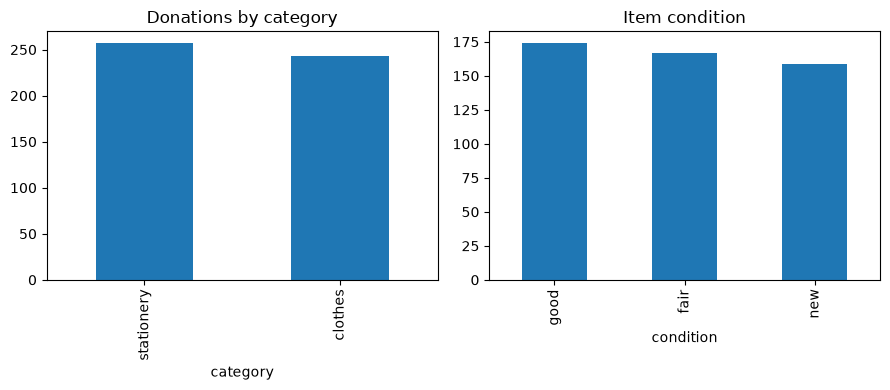

In [3]:
fig, axes = plt.subplots(1, 2)
donations['category'].value_counts().plot.bar(ax=axes[0], title='Donations by category');
donations['condition'].value_counts().plot.bar(ax=axes[1], title='Item condition');
plt.tight_layout(); plt.show()

### Urgency & timeline of requests (the matching workload)

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_11468\3313372644.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  requests['days_left'] = (requests['deadline'] - dt.datetime.utcnow()).dt.days


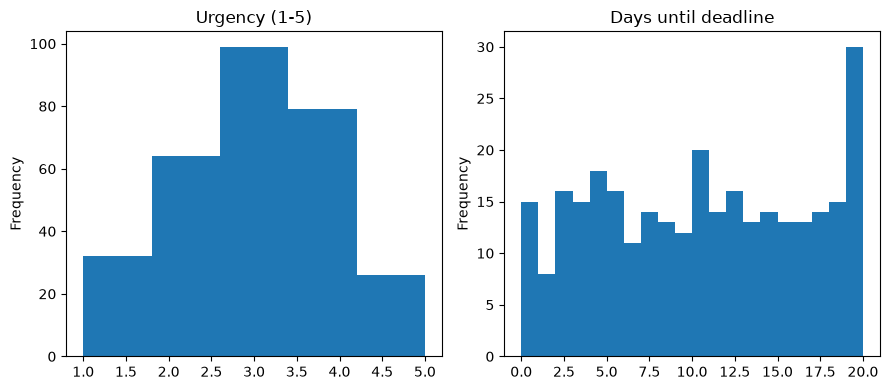

In [4]:
import datetime as dt
requests['deadline'] = pd.to_datetime(requests['deadline'])
requests['days_left'] = (requests['deadline'] - dt.datetime.utcnow()).dt.days
fig, axes = plt.subplots(1, 2)
requests['urgency'].plot.hist(bins=5, ax=axes[0], title='Urgency (1-5)');
requests['days_left'].plot.hist(bins=20, ax=axes[1], title='Days until deadline');
plt.tight_layout(); plt.show()

### Geographic spread (donors + NGO need locations)

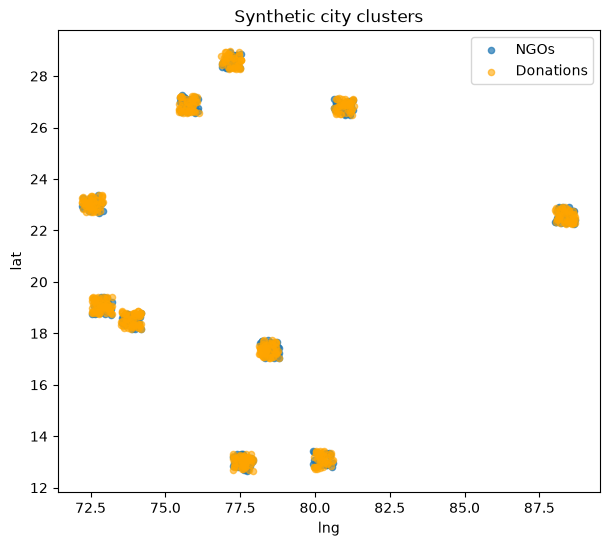

In [5]:
ngos = pd.read_csv(OUT/'ngos.csv')
fig, ax = plt.subplots(figsize=(7, 6))
ngos.plot.scatter('lng', 'lat', ax=ax, label='NGOs', alpha=.7)
donations.plot.scatter('lng', 'lat', ax=ax, color='orange', label='Donations', alpha=.6)
ax.set_title('Synthetic city clusters'); ax.legend(); plt.show()

### Ground-truth ideal matches

In [6]:
per_donation = ideal.groupby('donation_id').size()
per_donation.describe()

count    95.000000
mean      1.200000
std       0.496798
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       4.000000
dtype: float64

Summary: the synthetic benchmark spans 10 cities. Ground truth is constrained to the same city cluster (<= 25 km), so good ranking must prefer location-relevant requests over globally 'similar' text matches.